# Pandemic Mortality Rate Analysis — Statistical Comparison Notebook

This notebook creates a **dummy annual mortality-rate dataset** and demonstrates how to test whether mortality rates during the pandemic period were meaningfully higher than:

1. The previous year
2. Expected mortality rates based on pre-2021 trends and mortality improvement factors
3. Later post-pandemic years, especially 2024–2025

The dummy data structure is:

- Rows: calendar years 1950–2025
- Columns: ages 50–100
- Values: annual mortality rate, `qx`, meaning probability of death between age `x` and `x+1`

The notebook is written so you can later replace the dummy dataframe with real HMD / CDC / portfolio mortality data.

Main pandemic years tested:

- 2021
- 2022
- 2023

Comparison years:

- Pre-pandemic baseline: 2000–2020
- Later period: 2024–2025


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 180)

RANDOM_SEED = 123
rng = np.random.default_rng(RANDOM_SEED)

AGES = np.arange(50, 101)
YEARS = np.arange(1950, 2026)

COHORTS = {
    "50-74": list(range(50, 75)),
    "75-89": list(range(75, 90)),
    "90-100": list(range(90, 101)),
}

PRE_PANDEMIC_START = 2000
PRE_PANDEMIC_END = 2020

PANDEMIC_YEARS = [2021, 2022, 2023]
LATER_YEARS = [2024, 2025]


## 1. Create dummy mortality-rate dataframe

In [2]:
def make_dummy_pandemic_mortality(years, ages, seed=123):
    rng = np.random.default_rng(seed)
    rows = []

    for year in years:
        years_since_1950 = year - 1950
        row = {"Year": year}

        for age in ages:
            # Base Gompertz-like mortality shape at 1950
            base_q_1950 = 0.007 * np.exp(0.085 * (age - 50))

            # Age-specific historical improvement
            if age <= 74:
                annual_improvement = 0.013
            elif age <= 89:
                annual_improvement = 0.009
            else:
                annual_improvement = 0.004

            expected_trend = base_q_1950 * ((1 - annual_improvement) ** years_since_1950)

            # Pandemic excess mortality multipliers
            # These are dummy values designed to create a visible signal.
            pandemic_multiplier = 1.0

            if year == 2021:
                if age <= 74:
                    pandemic_multiplier *= 1.22
                elif age <= 89:
                    pandemic_multiplier *= 1.18
                else:
                    pandemic_multiplier *= 1.12

            elif year == 2022:
                if age <= 74:
                    pandemic_multiplier *= 1.15
                elif age <= 89:
                    pandemic_multiplier *= 1.12
                else:
                    pandemic_multiplier *= 1.08

            elif year == 2023:
                if age <= 74:
                    pandemic_multiplier *= 1.06
                elif age <= 89:
                    pandemic_multiplier *= 1.05
                else:
                    pandemic_multiplier *= 1.03

            elif year == 2024:
                # Partial normalization, but still slightly elevated for older ages
                if age <= 74:
                    pandemic_multiplier *= 1.01
                elif age <= 89:
                    pandemic_multiplier *= 1.02
                else:
                    pandemic_multiplier *= 1.02

            elif year == 2025:
                # Close to expected trend in this dummy dataset
                pandemic_multiplier *= 1.00

            # Random noise; older ages are noisier
            noise_sd = 0.012 if age <= 74 else 0.020 if age <= 89 else 0.035
            noise = rng.normal(0, noise_sd)

            q = expected_trend * pandemic_multiplier * np.exp(noise)
            q = np.clip(q, 0.0005, 0.75)

            row[age] = q

        rows.append(row)

    qx = pd.DataFrame(rows).set_index("Year")
    qx.columns.name = "Age"
    return qx


qx = make_dummy_pandemic_mortality(YEARS, AGES)

print("Dummy qx dataframe: rows are years, columns are ages, values are annual death probabilities")
display(qx.head())
display(qx.tail())


Dummy qx dataframe: rows are years, columns are ages, values are annual death probabilities


Age,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,...,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100
Year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1950,0.006917,0.007587,0.008426,0.009054,0.009944,0.010782,0.011568,0.012774,0.013765,0.014985,0.016397,0.017507,0.019692,0.020965,0.023287,...,0.151883,0.168367,0.180508,0.191537,0.215163,0.218493,0.261375,0.269194,0.287818,0.313733,0.348543,0.375089,0.448567,0.439560,0.491298
1951,0.006911,0.007524,0.008195,0.008864,0.009639,0.010459,0.011302,0.012559,0.013800,0.014751,0.016057,0.017532,0.019054,0.020503,0.023086,...,0.147144,0.162442,0.175080,0.195696,0.210016,0.231306,0.246336,0.282294,0.281215,0.316169,0.333894,0.389873,0.424819,0.440914,0.517980
1952,0.006795,0.007302,0.008056,0.008838,0.009554,0.010718,0.011473,0.012623,0.013686,0.014361,0.015882,0.016810,0.018765,0.020866,0.022190,...,0.149571,0.158976,0.172518,0.190524,0.209057,0.221498,0.250202,0.278019,0.294042,0.336176,0.351516,0.375193,0.412156,0.438470,0.469561
1953,0.006769,0.007253,0.007944,0.008676,0.009500,0.010352,0.011216,0.011923,0.013252,0.014330,0.015726,0.017349,0.018846,0.020375,0.022258,...,0.149773,0.159758,0.174659,0.190714,0.200763,0.226615,0.246940,0.265955,0.280235,0.322183,0.325655,0.363613,0.397645,0.438983,0.499359
1954,0.006776,0.007383,0.007951,0.008618,0.009075,0.010300,0.011417,0.012110,0.013149,0.014396,0.015679,0.016949,0.018340,0.020144,0.021480,...,0.144978,0.160506,0.167905,0.189888,0.201277,0.225887,0.243501,0.267244,0.305919,0.325617,0.335680,0.339714,0.420396,0.455600,0.485739


Age,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,...,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100
Year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2021,0.003352,0.003765,0.004024,0.004449,0.004594,0.005159,0.005673,0.006143,0.006664,0.007172,0.008024,0.008538,0.009545,0.010197,0.011249,...,0.090756,0.103149,0.107482,0.116555,0.184069,0.192051,0.195370,0.231668,0.240117,0.269476,0.299461,0.342138,0.356809,0.364583,0.433152
2022,0.003115,0.003373,0.003745,0.004069,0.004335,0.004846,0.005216,0.005818,0.006088,0.006695,0.007445,0.008008,0.008672,0.009527,0.009993,...,0.086718,0.094828,0.105128,0.112180,0.173550,0.171653,0.193891,0.214710,0.247021,0.254606,0.288726,0.302119,0.322906,0.361225,0.393865
2023,0.002879,0.003138,0.003421,0.003746,0.004017,0.004294,0.004690,0.005156,0.005721,0.006066,0.006589,0.007307,0.007864,0.008728,0.009332,...,0.083941,0.089776,0.098131,0.106111,0.167703,0.171553,0.206637,0.204097,0.221838,0.258889,0.291911,0.301801,0.328423,0.339680,0.373943
2024,0.002654,0.002897,0.003251,0.003408,0.003814,0.004167,0.004463,0.004881,0.005077,0.005784,0.006214,0.006657,0.007487,0.008021,0.008810,...,0.078439,0.086022,0.090269,0.099619,0.157781,0.168299,0.186207,0.218653,0.228242,0.245495,0.273137,0.280296,0.298343,0.337446,0.374572
2025,0.002632,0.002841,0.003043,0.003402,0.003646,0.003977,0.004412,0.004755,0.005280,0.005629,0.006131,0.006661,0.007278,0.007889,0.008615,...,0.076121,0.081725,0.090592,0.098891,0.150871,0.169836,0.197192,0.207783,0.233438,0.238420,0.254143,0.273497,0.300652,0.365679,0.347426


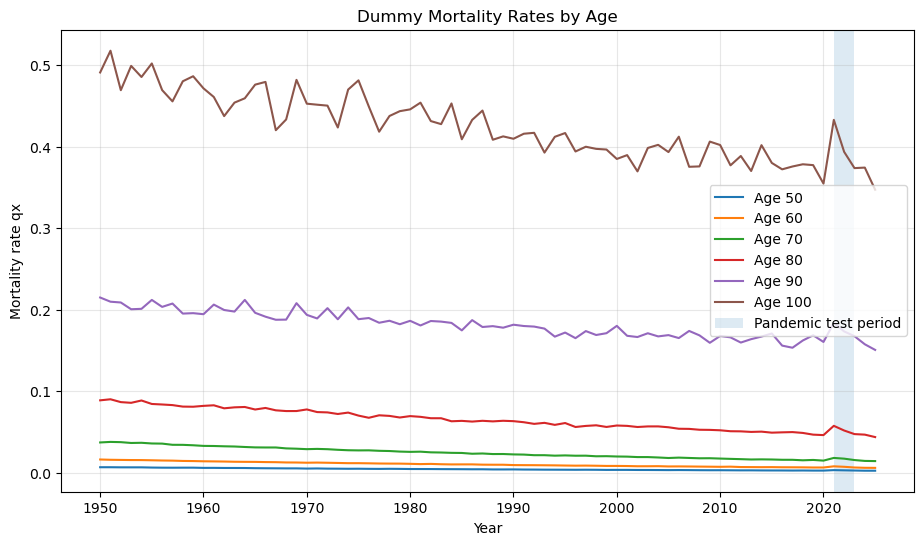

In [5]:
plt.figure(figsize=(11, 6))
for age in [50, 60, 70, 80, 90, 100]:
    plt.plot(qx.index, qx[age], label=f"Age {age}")

plt.axvspan(2021, 2023, alpha=0.15, label="Pandemic test period")
plt.title("Dummy Mortality Rates by Age")
plt.xlabel("Year")
plt.ylabel("Mortality rate qx")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 2. Cohort averages

,50-74,75-89,90-100
Year,,,
2015,0.009994,0.062836,0.259311
2016,0.009811,0.062239,0.257262
2017,0.009666,0.061769,0.254802
2018,0.009574,0.061683,0.258116
2019,0.009457,0.060403,0.252308
2020,0.009306,0.060194,0.245314
2021,0.011193,0.070263,0.282627
2022,0.010437,0.066524,0.265843
2023,0.009462,0.062179,0.260589


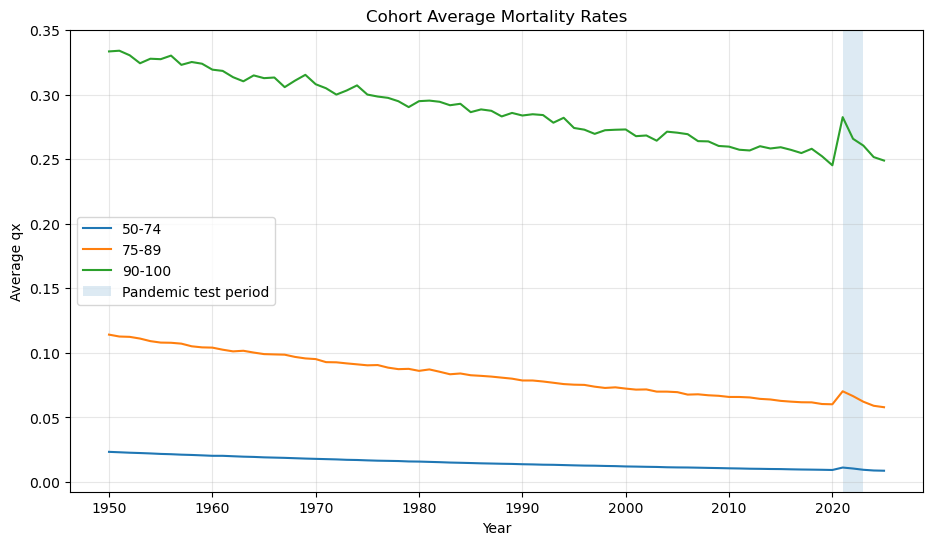

In [6]:
def cohort_average(df, cohorts):
    out = pd.DataFrame(index=df.index)
    for name, ages in cohorts.items():
        available = [age for age in ages if age in df.columns]
        out[name] = df[available].mean(axis=1)
    return out

qx_cohort = cohort_average(qx, COHORTS)

display(qx_cohort.loc[2015:2025])

plt.figure(figsize=(11, 6))
for cohort in qx_cohort.columns:
    plt.plot(qx_cohort.index, qx_cohort[cohort], label=cohort)

plt.axvspan(2021, 2023, alpha=0.15, label="Pandemic test period")
plt.title("Cohort Average Mortality Rates")
plt.xlabel("Year")
plt.ylabel("Average qx")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 3. Year-over-year test: was mortality higher than the previous year?

In [7]:
# For each pandemic year, compare age-level qx against the previous year.
#
# Null hypothesis:
# observed qx in year t is not higher than qx in year t-1
#
# We use:
# - paired t-test across ages within each cohort
# - Wilcoxon signed-rank test as a non-parametric check
#
# In real actuarial work, if you have deaths and exposures, use a binomial or Poisson model instead.

def yoy_tests(qx, years_to_test, cohorts):
    rows = []

    for year in years_to_test:
        prev_year = year - 1

        for cohort, ages in cohorts.items():
            ages = [age for age in ages if age in qx.columns]

            observed = qx.loc[year, ages]
            previous = qx.loc[prev_year, ages]
            diff = observed - previous
            rel_diff = observed / previous - 1

            t_stat, t_p = stats.ttest_rel(observed, previous, alternative="greater")

            try:
                w_stat, w_p = stats.wilcoxon(diff, alternative="greater")
            except ValueError:
                w_stat, w_p = np.nan, np.nan

            rows.append({
                "Year": year,
                "Cohort": cohort,
                "Mean observed qx": observed.mean(),
                "Mean previous qx": previous.mean(),
                "Mean absolute difference": diff.mean(),
                "Mean relative difference": rel_diff.mean(),
                "Paired t-test p-value": t_p,
                "Wilcoxon p-value": w_p,
                "Meaningfully higher at 5%?": bool(t_p < 0.05 and diff.mean() > 0),
            })

    return pd.DataFrame(rows)

yoy_results = yoy_tests(qx, PANDEMIC_YEARS, COHORTS)
display(yoy_results)


,Year,Cohort,Mean observed qx,Mean previous qx,Mean absolute difference,Mean relative difference,Paired t-test p-value,Wilcoxon p-value,Meaningfully higher at 5%?
0,2021,50-74,0.011193,0.009306,0.001887,0.204607,5.451815e-09,2.980232e-08,True
1,2021,75-89,0.070263,0.060194,0.010068,0.172200,1.733683e-08,3.051758e-05,True
2,2021,90-100,0.282627,0.245314,0.037312,0.149645,5.241632e-05,4.882812e-04,True
3,2022,50-74,0.010437,0.011193,-0.000756,-0.070822,1.000000e+00,1.000000e+00,False
4,2022,75-89,0.066524,0.070263,-0.003739,-0.056669,9.999992e-01,1.000000e+00,False
5,2022,90-100,0.265843,0.282627,-0.016784,-0.056209,9.975256e-01,9.985352e-01,False
6,2023,50-74,0.009462,0.010437,-0.000975,-0.090568,9.999999e-01,1.000000e+00,False
7,2023,75-89,0.062179,0.066524,-0.004345,-0.067085,1.000000e+00,1.000000e+00,False
8,2023,90-100,0.260589,0.265843,-0.005254,-0.016932,9.034299e-01,8.798828e-01,False


## 4. Estimate expected mortality using pre-2021 improvement factors

In [8]:
# Mortality improvement factor:
# MI_x,t = 1 - q_x,t / q_x,t-1
#
# We estimate improvement using pre-pandemic data only:
# 2000-2020.
#
# Then we project expected qx for 2021-2025 from the 2020 base mortality table.

mi = 1 - qx / qx.shift(1)
mi = mi.dropna()

pre_pandemic_mi = mi.loc[PRE_PANDEMIC_START:PRE_PANDEMIC_END]

# Smooth by taking the average improvement by age over the pre-pandemic period
mi_expected_by_age = pre_pandemic_mi.mean()

# Apply caps for stability
mi_expected_by_age = mi_expected_by_age.clip(lower=-0.01, upper=0.03)

base_qx_2020 = qx.loc[2020]

expected_qx = pd.DataFrame(index=np.arange(2021, 2026), columns=AGES, dtype=float)

for age in AGES:
    q = base_qx_2020.loc[age]
    mi_age = mi_expected_by_age.loc[age]

    for year in expected_qx.index:
        q = q * (1 - mi_age)
        expected_qx.loc[year, age] = q

print("Expected mortality rates based only on pre-2021 improvement assumptions")
display(expected_qx.head())

expected_cohort = cohort_average(expected_qx, COHORTS)
observed_cohort_2021_2025 = qx_cohort.loc[2021:2025]

comparison_cohort = pd.concat(
    {"Observed": observed_cohort_2021_2025, "Expected": expected_cohort},
    axis=1
)

display(comparison_cohort)


Expected mortality rates based only on pre-2021 improvement assumptions


,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,...,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100
2021,0.002749,0.003043,0.003272,0.003522,0.003961,0.004246,0.004671,0.004996,0.005401,0.005979,0.006513,0.007089,0.007731,0.008274,0.009314,...,0.079313,0.083350,0.091893,0.102899,0.160280,0.164031,0.186305,0.206366,0.211571,0.216778,0.254119,0.298203,0.296274,0.340991,0.353482
2022,0.002714,0.003007,0.003230,0.003474,0.003915,0.004193,0.004615,0.004928,0.005331,0.005907,0.006436,0.007001,0.007631,0.008165,0.009205,...,0.078661,0.082467,0.091018,0.101992,0.159928,0.163244,0.185684,0.206803,0.210552,0.214769,0.253231,0.298527,0.294595,0.339048,0.352019
2023,0.002681,0.002971,0.003188,0.003427,0.003869,0.004141,0.004559,0.004861,0.005262,0.005835,0.006359,0.006914,0.007533,0.008057,0.009098,...,0.078015,0.081594,0.090150,0.101092,0.159577,0.162461,0.185066,0.207240,0.209538,0.212779,0.252346,0.298852,0.292926,0.337117,0.350562
2024,0.002647,0.002936,0.003146,0.003381,0.003824,0.004089,0.004504,0.004794,0.005195,0.005764,0.006284,0.006828,0.007435,0.007950,0.008992,...,0.077373,0.080730,0.089291,0.100201,0.159226,0.161682,0.184450,0.207679,0.208529,0.210807,0.251464,0.299176,0.291267,0.335197,0.349110
2025,0.002614,0.002901,0.003106,0.003335,0.003779,0.004038,0.004450,0.004729,0.005128,0.005694,0.006209,0.006743,0.007339,0.007845,0.008887,...,0.076738,0.079875,0.088440,0.099317,0.158877,0.160907,0.183836,0.208119,0.207525,0.208854,0.250586,0.299501,0.289616,0.333287,0.347665


Observed                      Expected                    
         50-74     75-89    90-100     50-74     75-89    90-100
2021  0.011193  0.070263  0.282627  0.009185  0.059656  0.244400
2022  0.010437  0.066524  0.265843  0.009065  0.059122  0.243491
2023  0.009462  0.062179  0.260589  0.008947  0.058594  0.242588
2024  0.008911  0.059035  0.251679  0.008831  0.058070  0.241690
2025  0.008731  0.057922  0.248994  0.008716  0.057551  0.240798

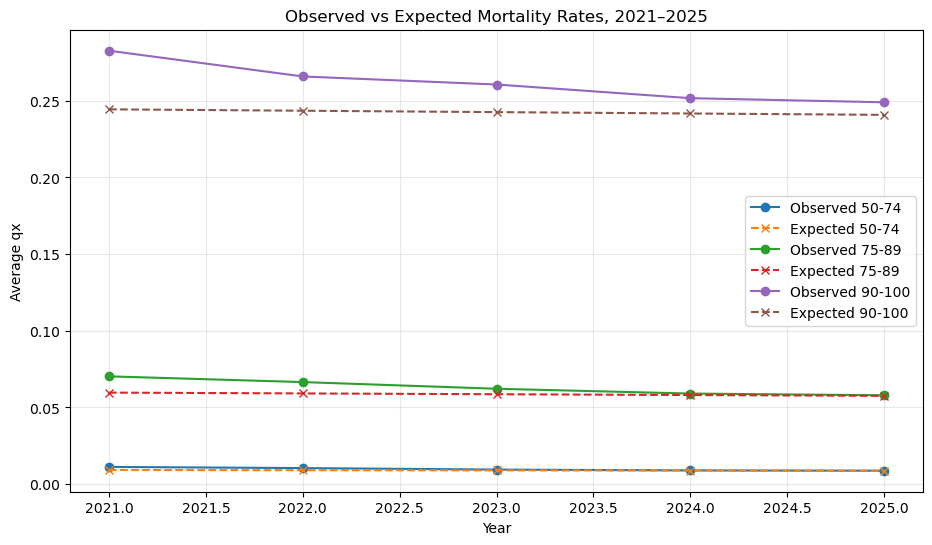

In [9]:
plt.figure(figsize=(11, 6))
for cohort in COHORTS:
    plt.plot(observed_cohort_2021_2025.index, observed_cohort_2021_2025[cohort], marker="o", label=f"Observed {cohort}")
    plt.plot(expected_cohort.index, expected_cohort[cohort], linestyle="--", marker="x", label=f"Expected {cohort}")

plt.title("Observed vs Expected Mortality Rates, 2021–2025")
plt.xlabel("Year")
plt.ylabel("Average qx")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 5. Test observed mortality vs expected mortality

In [10]:
# For each year and cohort:
# observed qx is compared with expected qx calculated from pre-2021 improvement.
#
# Null hypothesis:
# observed qx is not higher than expected qx.
#
# Alternative:
# observed qx is higher than expected qx.

def observed_vs_expected_tests(qx, expected_qx, years_to_test, cohorts):
    rows = []

    for year in years_to_test:
        for cohort, ages in cohorts.items():
            ages = [age for age in ages if age in qx.columns]

            observed = qx.loc[year, ages]
            expected = expected_qx.loc[year, ages]
            diff = observed - expected
            ratio = observed / expected

            t_stat, t_p = stats.ttest_rel(observed, expected, alternative="greater")

            try:
                w_stat, w_p = stats.wilcoxon(diff, alternative="greater")
            except ValueError:
                w_stat, w_p = np.nan, np.nan

            rows.append({
                "Year": year,
                "Cohort": cohort,
                "Mean observed qx": observed.mean(),
                "Mean expected qx": expected.mean(),
                "Observed / expected": ratio.mean(),
                "Excess over expected": diff.mean(),
                "Paired t-test p-value": t_p,
                "Wilcoxon p-value": w_p,
                "Meaningfully higher than expected at 5%?": bool(t_p < 0.05 and diff.mean() > 0),
            })

    return pd.DataFrame(rows)

ove_results = observed_vs_expected_tests(
    qx=qx,
    expected_qx=expected_qx,
    years_to_test=[2021, 2022, 2023, 2024, 2025],
    cohorts=COHORTS,
)

display(ove_results)


,Year,Cohort,Mean observed qx,Mean expected qx,Observed / expected,Excess over expected,Paired t-test p-value,Wilcoxon p-value,Meaningfully higher than expected at 5%?
0,2021,50-74,0.011193,0.009185,1.220292,0.002008,5.656891e-09,2.980232e-08,True
1,2021,75-89,0.070263,0.059656,1.182685,0.010607,1.786445e-08,3.051758e-05,True
2,2021,90-100,0.282627,0.244400,1.153926,0.038227,4.898535e-05,4.882812e-04,True
3,2022,50-74,0.010437,0.009065,1.148448,0.001372,3.597941e-08,2.980232e-08,True
4,2022,75-89,0.066524,0.059122,1.125128,0.007401,1.909655e-07,3.051758e-05,True
5,2022,90-100,0.265843,0.243491,1.091854,0.022352,2.368120e-04,4.882812e-04,True
6,2023,50-74,0.009462,0.008947,1.057859,0.000515,6.867464e-08,2.980232e-08,True
7,2023,75-89,0.062179,0.058594,1.058664,0.003585,2.556122e-05,6.103516e-05,True
8,2023,90-100,0.260589,0.242588,1.076892,0.018001,2.356140e-03,2.441406e-03,True
9,2024,50-74,0.008911,0.008831,1.006422,0.000081,1.529952e-02,1.708689e-02,True


## 6. Were 2021–2022 mortality rates higher than 2024–2025?

In [11]:
# Compare average qx in 2021-2022 with average qx in 2024-2025.
#
# This answers:
# Can the data show whether mortality rates in 2021-2022 were higher than 2024-2025?
#
# We compare age-level cohort mortality rates:
# mean(qx_2021, qx_2022) vs mean(qx_2024, qx_2025)

def compare_pandemic_vs_later(qx, cohorts, early_years=[2021, 2022], later_years=[2024, 2025]):
    rows = []

    for cohort, ages in cohorts.items():
        ages = [age for age in ages if age in qx.columns]

        early = qx.loc[early_years, ages].mean(axis=0)
        later = qx.loc[later_years, ages].mean(axis=0)

        diff = early - later
        ratio = early / later

        t_stat, t_p = stats.ttest_rel(early, later, alternative="greater")

        try:
            w_stat, w_p = stats.wilcoxon(diff, alternative="greater")
        except ValueError:
            w_stat, w_p = np.nan, np.nan

        rows.append({
            "Cohort": cohort,
            "Mean qx 2021-2022": early.mean(),
            "Mean qx 2024-2025": later.mean(),
            "Ratio early / later": ratio.mean(),
            "Difference early - later": diff.mean(),
            "Paired t-test p-value": t_p,
            "Wilcoxon p-value": w_p,
            "2021-2022 meaningfully higher than 2024-2025 at 5%?": bool(t_p < 0.05 and diff.mean() > 0),
        })

    return pd.DataFrame(rows)

early_vs_later_results = compare_pandemic_vs_later(qx, COHORTS)
display(early_vs_later_results)


,Cohort,Mean qx 2021-2022,Mean qx 2024-2025,Ratio early / later,Difference early - later,Paired t-test p-value,Wilcoxon p-value,2021-2022 meaningfully higher than 2024-2025 at 5%?
0,50-74,0.010815,0.008821,1.228184,0.001994,6.167472e-09,2.980232e-08,True
1,75-89,0.068393,0.058478,1.170746,0.009915,2.964759e-08,3.051758e-05,True
2,90-100,0.274235,0.250337,1.093255,0.023898,3.227904e-04,4.882812e-04,True


## 7. Excess mortality ratios by year and cohort

,50-74,75-89,90-100
Year,,,
2021,1.220292,1.182685,1.153926
2022,1.148448,1.125128,1.091854
2023,1.057859,1.058664,1.076892
2024,1.006422,1.018103,1.043664
2025,0.998945,1.006944,1.036776


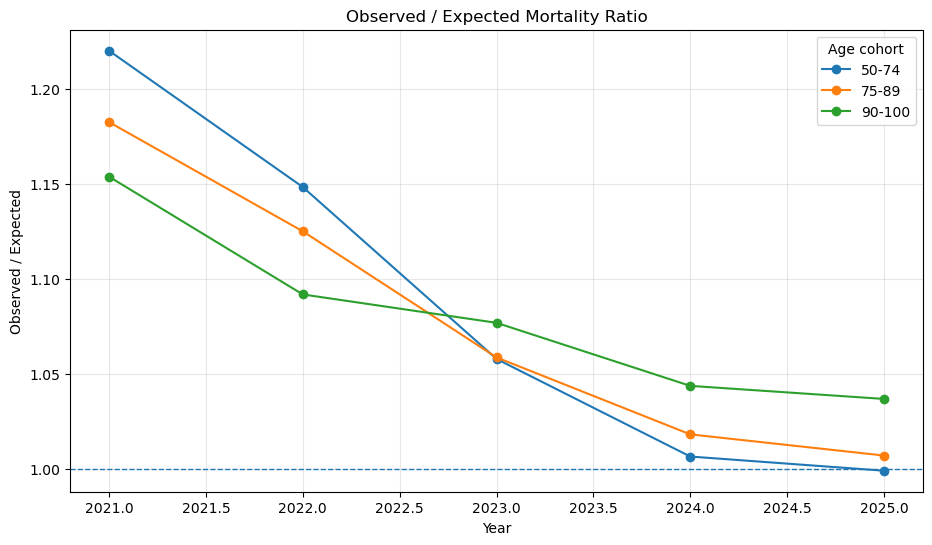

In [12]:
# Excess mortality ratio:
# observed qx / expected qx
#
# Values:
# - 1.00 = observed equals expected
# - 1.10 = observed is 10% higher than expected
# - 0.95 = observed is 5% lower than expected

excess_ratio = qx.loc[2021:2025, AGES] / expected_qx
excess_ratio_cohort = cohort_average(excess_ratio, COHORTS)

display(excess_ratio_cohort)

plt.figure(figsize=(11, 6))
for cohort in excess_ratio_cohort.columns:
    plt.plot(excess_ratio_cohort.index, excess_ratio_cohort[cohort], marker="o", label=cohort)

plt.axhline(1.0, linestyle="--", linewidth=1)
plt.title("Observed / Expected Mortality Ratio")
plt.xlabel("Year")
plt.ylabel("Observed / Expected")
plt.legend(title="Age cohort")
plt.grid(True, alpha=0.3)
plt.show()


## 8. Bootstrap uncertainty check

In [13]:
# Bootstrap confidence intervals for observed / expected ratio.
#
# We resample ages within each cohort to estimate uncertainty in the cohort-level O/E ratio.
# This is useful for dummy data and exploratory analysis.
#
# For real mortality analysis, deaths and exposure counts are preferable because they let you
# use Poisson/binomial credibility intervals.

def bootstrap_oe_ratio(qx, expected_qx, year, ages, n_boot=5000, seed=123):
    rng = np.random.default_rng(seed)
    ages = np.array(ages)
    ratios = []

    for _ in range(n_boot):
        sampled_ages = rng.choice(ages, size=len(ages), replace=True)
        observed = qx.loc[year, sampled_ages].mean()
        expected = expected_qx.loc[year, sampled_ages].mean()
        ratios.append(observed / expected)

    ratios = np.array(ratios)
    return {
        "mean": ratios.mean(),
        "lower_95": np.quantile(ratios, 0.025),
        "upper_95": np.quantile(ratios, 0.975),
    }

bootstrap_rows = []

for year in [2021, 2022, 2023, 2024, 2025]:
    for cohort, ages in COHORTS.items():
        boot = bootstrap_oe_ratio(qx, expected_qx, year, ages, n_boot=3000, seed=year)
        bootstrap_rows.append({
            "Year": year,
            "Cohort": cohort,
            "Bootstrap mean O/E": boot["mean"],
            "Lower 95% CI": boot["lower_95"],
            "Upper 95% CI": boot["upper_95"],
            "CI entirely above 1?": bool(boot["lower_95"] > 1.0),
        })

bootstrap_results = pd.DataFrame(bootstrap_rows)
display(bootstrap_results)


,Year,Cohort,Bootstrap mean O/E,Lower 95% CI,Upper 95% CI,CI entirely above 1?
0,2021,50-74,1.218883,1.208836,1.229000,True
1,2021,75-89,1.178055,1.159001,1.198732,True
2,2021,90-100,1.156220,1.118192,1.190442,True
3,2022,50-74,1.151143,1.141311,1.161003,True
4,2022,75-89,1.125138,1.110078,1.139266,True
5,2022,90-100,1.091917,1.060650,1.123525,True
6,2023,50-74,1.057568,1.050024,1.065950,True
7,2023,75-89,1.061064,1.047354,1.074730,True
8,2023,90-100,1.074449,1.037300,1.115152,True
9,2024,50-74,1.009029,1.002106,1.016185,True


## 9. Interpretation template

Use the output tables as follows:

### A. Higher than previous year

Look at the **year-over-year test**.

A year is meaningfully higher than the previous year when:

- Mean relative difference is positive
- Paired t-test p-value is below 0.05
- Wilcoxon p-value also supports the direction

### B. Higher than expected

Look at the **observed vs expected** table.

A year is meaningfully higher than expected when:

- Observed / expected ratio is above 1.00
- Excess over expected is positive
- p-value is below 0.05
- Bootstrap confidence interval is entirely above 1.00

### C. 2021–2022 vs 2024–2025

Look at the **early pandemic vs later years** table.

The data supports 2021–2022 being higher than 2024–2025 when:

- Ratio early / later is above 1.00
- Difference early - later is positive
- p-value is below 0.05

### D. Important actuarial caveat

This notebook uses mortality rates directly and treats ages inside a cohort as paired observations.

For a production mortality study, use:

- Death counts
- Central exposure or initial exposure
- Age-sex-calendar year cells
- Binomial, Poisson, or logistic regression models
- Credibility weighting for sparse ages
- Separate tests by sex, geography, socioeconomic segment, and underwriting group if available


In [14]:
# Optional exports

qx.to_csv("dummy_qx_1950_2025_pandemic_analysis.csv")
expected_qx.to_csv("expected_qx_2021_2025_from_pre2021_improvement.csv")
yoy_results.to_csv("year_over_year_pandemic_tests.csv", index=False)
ove_results.to_csv("observed_vs_expected_pandemic_tests.csv", index=False)
early_vs_later_results.to_csv("pandemic_2021_2022_vs_2024_2025_tests.csv", index=False)
bootstrap_results.to_csv("bootstrap_observed_expected_results.csv", index=False)

print("Exported analysis files.")


Exported analysis files.
